In [1]:
import cv2
import keras
import pathlib
import PIL.Image
import numpy as np
import tensorflow as tf
from keras import layers
import matplotlib.pyplot as plt
from keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

In [2]:
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Classifier


In [3]:
IMAGE_SHAPE = (224, 224)

clf = keras.applications.MobileNetV2(
    input_shape=(IMAGE_SHAPE + (3,)), include_top=True, weights="imagenet"
)


2026-01-09 21:33:09.308825: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-01-09 21:33:09.309028: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-01-09 21:33:09.309042: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-01-09 21:33:09.309598: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-09 21:33:09.309612: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
import PIL
import cv2

img = PIL.Image.open("./datasets/goldfish.jpg").resize(IMAGE_SHAPE)
x = np.array(img)
x = preprocess_input(x)
x = np.expand_dims(x, axis=0)
x.shape

(1, 224, 224, 3)

In [5]:
y_hat = clf.predict(x)
y_hat

2026-01-09 21:33:11.482849: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([[4.70468338e-04, 9.16943371e-01, 3.13432502e-05, 5.36560183e-05,
        5.37430824e-05, 1.17602169e-04, 2.28351655e-05, 8.45745744e-05,
        3.85363703e-04, 9.93532831e-06, 6.44216780e-05, 7.67937818e-05,
        1.79946830e-04, 4.33293972e-05, 3.55996672e-05, 4.08252636e-05,
        1.10281428e-04, 3.72930845e-05, 2.81318626e-05, 1.85783010e-05,
        2.28072877e-05, 7.34962669e-05, 5.62207315e-05, 5.52068777e-05,
        2.23230367e-04, 1.33642141e-04, 1.78091053e-04, 1.46277729e-04,
        5.11729631e-05, 1.97383342e-04, 9.06084970e-05, 7.12633628e-05,
        1.08521257e-04, 2.44604715e-04, 9.97210809e-05, 3.94347560e-04,
        2.38780573e-04, 2.94544385e-04, 6.41310617e-05, 6.84367114e-05,
        3.45879671e-05, 6.74670009e-05, 3.59893456e-04, 7.85751763e-05,
        3.07290102e-05, 5.38147287e-05, 6.71201342e-05, 1.34328177e-04,
        2.95878417e-05, 1.50281885e-05, 1.40647035e-05, 3.93025402e-04,
        4.29391439e-05, 8.33691229e-05, 6.19075945e-05, 2.509079

In [6]:
decoded = decode_predictions(y_hat)
decoded[0][:10]

[('n01443537', 'goldfish', 0.9169434),
 ('n02119789', 'kit_fox', 0.000755296),
 ('n03944341', 'pinwheel', 0.00074746745),
 ('n01818515', 'macaw', 0.0006337875),
 ('n01833805', 'hummingbird', 0.00061776786)]

In [7]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

dataset_dirname = tf.keras.utils.get_file(
    "flowers_dataset",
    origin=dataset_url,
    untar=True,
)


In [8]:
import pathlib

dir_pathname = pathlib.Path(dataset_dirname)
dir_pathname


PosixPath('/Users/sarveshmhadgut/.keras/datasets/flowers_dataset')

In [9]:
files = list(dir_pathname.rglob("*.jpg"))
print("Rows -> ", len(files))


Rows ->  3670


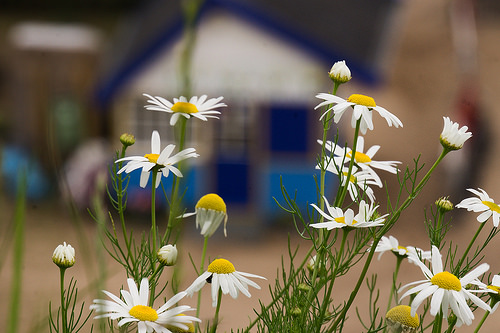

In [10]:
import random

n = random.randint(0, len(files) - 1)
PIL.Image.open(str(files[n]))


In [11]:
roses = list(dir_pathname.rglob("*/roses/*"))
print("Rows of Roses -> ", len(roses))

Rows of Roses ->  641


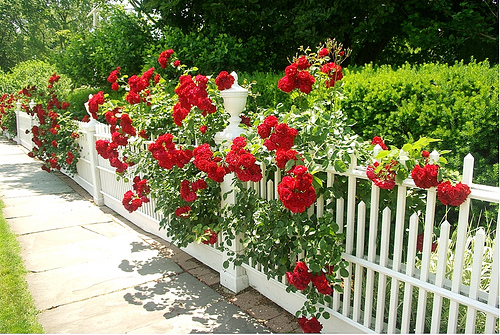

In [12]:
n = random.randint(0, len(roses) - 1)
PIL.Image.open(str(roses[n]))


In [13]:
flowers_dir_map = {
    "daisy": list(dir_pathname.rglob("*/daisy/*")),
    "dandelion": list(dir_pathname.rglob("*/dandelion/*")),
    "roses": list(dir_pathname.rglob("*/roses/*")),
    "sunflowers": list(dir_pathname.rglob("*/sunflowers/*")),
    "tulips": list(dir_pathname.rglob("*/tulips/*")),
}


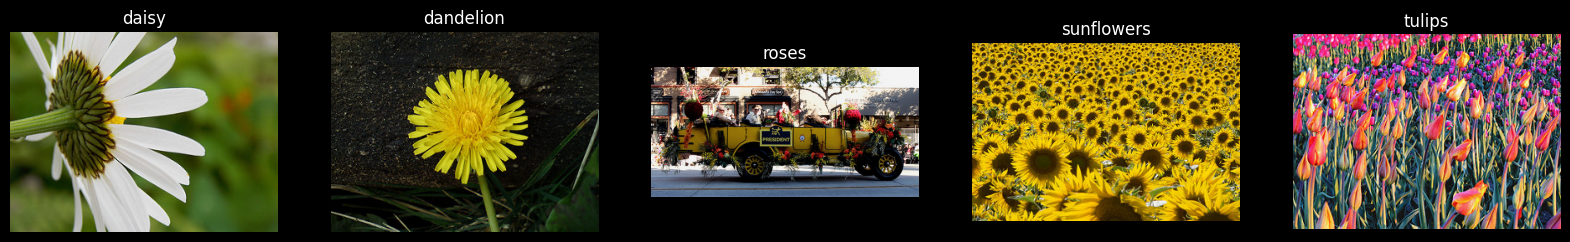

In [14]:
plt.figure(figsize=(20, 10))
for i, (name, path) in enumerate(flowers_dir_map.items()):
    ax = plt.subplot(1, 5, i + 1)

    img = cv2.imread(path[0])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")


In [15]:
X, y = [], []

for i, paths in enumerate(flowers_dir_map.values()):
    for path in paths:
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMAGE_SHAPE)

        X.append(img)
        y.append(i)


In [16]:
X = np.array(X)
X = preprocess_input(X)
y = np.array(y)

X.shape, y.shape

((3670, 224, 224, 3), (3670,))

In [17]:
rng = np.random.default_rng(seed=42)
idx = rng.choice(len(X), size=5, replace=False)

X_sample = X[idx]
y_sample = y[idx]


In [18]:
y_hat = clf.predict(X_sample)
y_hat

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


array([[2.55229883e-04, 1.70253566e-04, 1.79925235e-04, ...,
        1.68985128e-03, 6.42026076e-04, 2.16005428e-04],
       [1.74948582e-04, 6.42048893e-04, 3.62608233e-04, ...,
        3.32096060e-05, 1.67404383e-03, 2.92319339e-04],
       [6.16892008e-04, 4.90480452e-04, 1.29193009e-04, ...,
        7.35726266e-04, 2.83079431e-03, 8.55291146e-04],
       [1.14910275e-04, 4.86042933e-04, 3.02638422e-04, ...,
        1.33402922e-04, 9.71085159e-04, 9.92694125e-03],
       [8.92777643e-06, 2.74583865e-02, 1.47947367e-05, ...,
        9.06857196e-04, 9.65590698e-06, 4.22044395e-05]], dtype=float32)

In [19]:
decoded = decode_predictions(y_hat, top=3)
decoded

[[('n02206856', 'bee', 0.18045403),
  ('n01531178', 'goldfinch', 0.087380156),
  ('n12057211', "yellow_lady's_slipper", 0.069473855)],
 [('n02776631', 'bakery', 0.10717919),
  ('n01968897', 'chambered_nautilus', 0.06663474),
  ('n01943899', 'conch', 0.057190772)],
 [('n11939491', 'daisy', 0.104420416),
  ('n02206856', 'bee', 0.098153785),
  ('n07754684', 'jackfruit', 0.055063013)],
 [('n03794056', 'mousetrap', 0.07074603),
  ('n04398044', 'teapot', 0.049345955),
  ('n04209239', 'shower_curtain', 0.03623963)],
 [('n12620546', 'hip', 0.44661334),
  ('n11939491', 'daisy', 0.19309139),
  ('n01910747', 'jellyfish', 0.060801823)]]

In [20]:
for i, (preds, actual) in enumerate(zip(decoded, y_sample)):
    print(f"Image {i}: {list(flowers_dir_map.keys())[actual]}")
    for rank, (_, label, prob) in enumerate(preds, start=1):
        print(f"  {rank}) {label} ({prob:.3f})", end="\t\t")
    print("\n\n")

Image 0: sunflowers
  1) bee (0.180)		  2) goldfinch (0.087)		  3) yellow_lady's_slipper (0.069)		


Image 1: roses
  1) bakery (0.107)		  2) chambered_nautilus (0.067)		  3) conch (0.057)		


Image 2: sunflowers
  1) daisy (0.104)		  2) bee (0.098)		  3) jackfruit (0.055)		


Image 3: daisy
  1) mousetrap (0.071)		  2) teapot (0.049)		  3) shower_curtain (0.036)		


Image 4: roses
  1) hip (0.447)		  2) daisy (0.193)		  3) jellyfish (0.061)		




## Feature Extractor


In [21]:
model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights="imagenet"
)

model.trainable = False

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [23]:
num_classes = len(flowers_dir_map)
cnn = keras.Sequential(
    [
        model,
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(num_classes, activation="softmax"),
    ]
)


In [24]:
cnn.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
cnn.fit(
    X_train,
    y_train,
    batch_size=32,
    validation_data=(X_test, y_test),
    epochs=5,
)


Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 368ms/step - accuracy: 0.7279 - loss: 0.7518 - val_accuracy: 0.8719 - val_loss: 0.4259
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.8825 - loss: 0.3603 - val_accuracy: 0.8896 - val_loss: 0.3478
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 157ms/step - accuracy: 0.9111 - loss: 0.2803 - val_accuracy: 0.8787 - val_loss: 0.3427
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 158ms/step - accuracy: 0.9329 - loss: 0.2319 - val_accuracy: 0.8896 - val_loss: 0.3125
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - accuracy: 0.9407 - loss: 0.1989 - val_accuracy: 0.8856 - val_loss: 0.3240


In [28]:
cnn.evaluate(X_test, y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.8856 - loss: 0.3240


[0.3239884674549103, 0.8855586051940918]

In [29]:
y_hat = cnn.predict(X_test)
y_hat

23/23 ━━━━━━━━━━━━━━━━━━━━ 36s 631ms/step


array([[1.0589554e-05, 9.9945873e-01, 5.9577578e-05, 2.6218535e-04,
        2.0888491e-04],
       [9.8618016e-02, 8.9296710e-01, 5.6616114e-03, 1.8076158e-04,
        2.5725518e-03],
       [7.1088322e-03, 5.9787082e-05, 9.8436040e-01, 9.8141500e-05,
        8.3728638e-03],
       ...,
       [5.0272625e-03, 5.4928125e-04, 1.4044599e-02, 6.5490277e-04,
        9.7972393e-01],
       [9.7374177e-01, 1.0173348e-02, 6.2368246e-04, 1.3157478e-02,
        2.3037046e-03],
       [9.7865880e-01, 4.2731133e-03, 8.4741856e-04, 1.0816526e-02,
        5.4041818e-03]], dtype=float32)

In [30]:
y_hat = [np.argmax(y) for y in y_hat]
y_hat

[1,
 1,
 2,
 1,
 0,
 4,
 0,
 2,
 2,
 0,
 2,
 2,
 1,
 0,
 1,
 3,
 3,
 1,
 2,
 4,
 2,
 2,
 2,
 3,
 4,
 0,
 4,
 3,
 0,
 2,
 1,
 2,
 1,
 0,
 2,
 2,
 0,
 3,
 4,
 4,
 3,
 1,
 4,
 2,
 1,
 2,
 1,
 3,
 2,
 2,
 2,
 3,
 4,
 1,
 0,
 1,
 4,
 3,
 1,
 1,
 0,
 3,
 0,
 1,
 1,
 3,
 4,
 4,
 0,
 1,
 2,
 1,
 2,
 0,
 1,
 2,
 1,
 3,
 4,
 2,
 4,
 1,
 0,
 1,
 1,
 4,
 1,
 2,
 4,
 1,
 3,
 4,
 1,
 2,
 1,
 1,
 0,
 4,
 2,
 0,
 4,
 0,
 1,
 0,
 2,
 3,
 4,
 2,
 4,
 2,
 0,
 1,
 3,
 0,
 2,
 1,
 1,
 3,
 3,
 1,
 2,
 3,
 4,
 4,
 0,
 1,
 4,
 3,
 1,
 0,
 1,
 1,
 1,
 4,
 3,
 0,
 4,
 2,
 3,
 2,
 1,
 4,
 4,
 3,
 0,
 4,
 2,
 2,
 4,
 2,
 3,
 4,
 4,
 0,
 4,
 4,
 4,
 0,
 4,
 3,
 0,
 4,
 3,
 1,
 0,
 3,
 4,
 1,
 3,
 2,
 2,
 1,
 0,
 1,
 3,
 1,
 3,
 0,
 4,
 1,
 1,
 0,
 2,
 0,
 2,
 0,
 0,
 2,
 3,
 2,
 1,
 1,
 0,
 4,
 4,
 4,
 3,
 3,
 1,
 2,
 3,
 4,
 2,
 0,
 3,
 4,
 0,
 2,
 2,
 4,
 2,
 0,
 3,
 4,
 1,
 0,
 2,
 4,
 1,
 2,
 4,
 0,
 4,
 0,
 3,
 3,
 3,
 4,
 3,
 2,
 4,
 4,
 1,
 2,
 2,
 1,
 3,
 3,
 1,
 0,
 4,
 3,
 2,
 3,
 3,
 3,
 2,
 2,
 2,
 1,


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       127
           1       0.93      0.88      0.91       179
           2       0.81      0.91      0.86       128
           3       0.87      0.93      0.90       140
           4       0.94      0.82      0.88       160

    accuracy                           0.89       734
   macro avg       0.88      0.89      0.88       734
weighted avg       0.89      0.89      0.89       734

